In [1]:
import numpy as np
#decisionTreeCriteria = "log_loss" #Shannon entropy
decisionTreeCriteria = "gini"

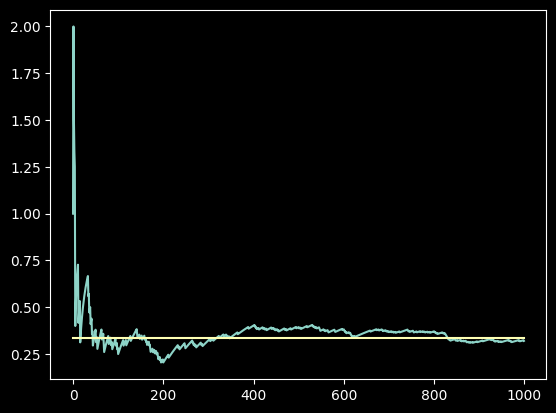

In [2]:
import matplotlib.pyplot as plt
import random
from itertools import accumulate

ROLLS = 1000

roll_dice = lambda : random.randint(1, 6)
outcome = lambda i: -3 if i == 6 else 1

x = [x for x in range(ROLLS)]

y = [outcome(roll_dice()) for _ in range(ROLLS)]
y = accumulate(y)
y = [y/i if not i == 0 else y for i, y in enumerate(y)]

plt.plot(x, y)
plt.plot(x, [1/3 for _ in range(ROLLS)])


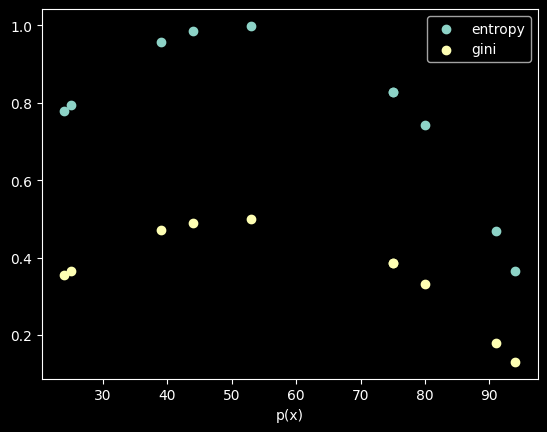

In [3]:

COINS = 10
heads = (np.random.rand(COINS) * 100).astype(int)
tails = 100 - heads
entropy = lambda x, y: -(x/(x+y) * np.log2(x/(x+y)) + y/(x+y) * np.log2(y/(x+y)))


gini = lambda x, y: 1 - ((x/(x+y))**2 + (y/(x+y))**2)
gini(heads, tails)

plt.scatter((heads/heads+tails), entropy(heads, tails), label='entropy')
plt.scatter((heads/heads+tails), gini(heads, tails), label='gini')
plt.xlabel('p(x)')
plt.legend()
plt.show()


In [4]:
import numpy as np
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target

# y.shape


In [5]:
# evaluate fra lektion 10:
def evaluate(H, Y, beta=1.0):
   tp = sum((Y == H) * (Y == 1) * 1)
   tn = sum((Y == H) * (Y == 0) * 1)
   fp = sum((Y != H) * (Y == 0) * 1)
   fn = sum((Y != H) * (Y == 1) * 1)

   accuracy = (tp + tn) / (tp + fp + fn + tn)
   sensitivity = tp / (tp + fn)
   specificity = tn / (fp + tn)
   precision = tp / (tp + fp)
   recall = sensitivity
   f_score = ( (beta**2 + 1) * precision * recall) / (beta**2 * precision + recall)
   auc = (sensitivity + specificity) / 2
   youden = sensitivity - (1 - specificity)
   p_plus = sensitivity / (1 - specificity)
   p_minus = (1 - sensitivity) / specificity
   dp = (np.sqrt(3) / np.pi) * (np.log(sensitivity/(1 - sensitivity) + np.log(specificity/(1 - specificity))))

   result = {}
   result["tp"] = tp
   result["tn"] = tn
   result["fp"] = fp
   result["fn"] = fn
   result["accuracy"] = accuracy
   result["sensitivity"] = sensitivity
   result["specificity"] = specificity
   result["precision"] = precision
   result["recall"] = recall
   result["f-score"] = f_score
   result["AUC"] = auc
   result["Youden"] = youden
   result["p+"] = p_plus
   result["p-"] = p_minus
   result["DP"] = dp

   return result


In [6]:

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split




In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15)


In [8]:
models = [('Decision Tree', DecisionTreeClassifier(criterion=decisionTreeCriteria)),
          ]
#

In [9]:
for name, model in models:
    print(f'** {name}')
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    print(evaluate(train_pred, y_train)['f-score'])
    print(evaluate(val_pred, y_val)['f-score'])


** Decision Tree
1.0
0.8


C:\Users\CMLyk\AppData\Local\Temp\ipykernel_28960\807902624.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  p_plus = sensitivity / (1 - specificity)
C:\Users\CMLyk\AppData\Local\Temp\ipykernel_28960\807902624.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  dp = (np.sqrt(3) / np.pi) * (np.log(sensitivity/(1 - sensitivity) + np.log(specificity/(1 - specificity))))


[Text(0.4444444444444444, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.666\nsamples = 107\nvalue = [34, 36, 37]'),
 Text(0.3333333333333333, 0.75, 'gini = 0.0\nsamples = 34\nvalue = [34, 0, 0]'),
 Text(0.38888888888888884, 0.8333333333333333, 'True  '),
 Text(0.5555555555555556, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 73\nvalue = [0, 36, 37]'),
 Text(0.5, 0.8333333333333333, '  False'),
 Text(0.4444444444444444, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.214\nsamples = 41\nvalue = [0, 36, 5]'),
 Text(0.2222222222222222, 0.4166666666666667, 'x[0] <= 4.95\ngini = 0.056\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 34\nvalue = [0, 34, 0]'),
 Text(0.6666666666666666, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.5555555555555556, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.7777777777777778, 0.25, 'x[2] <

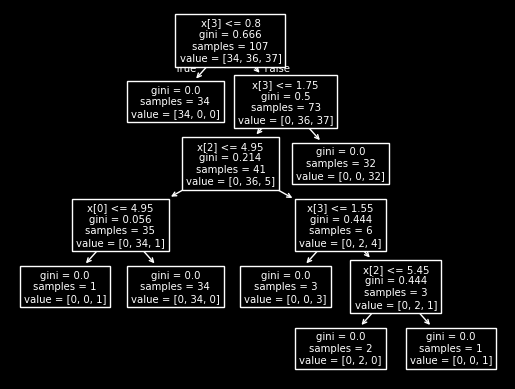

In [10]:
plot_tree(models[0][1])